# Track B OOF Mislabel Scoring

기존 `mislabel_score_v2_add`는 `base0` checkpoint가 본 train split과 보지 않은 validation split 사이의 exposure bias가 강하게 섞일 수 있다. 이 노트북은 `RS18A/train_labels.csv` 1366개 전체에 대해 5-fold out-of-fold prediction을 만들고, 각 샘플이 자기 자신을 학습에 포함하지 않은 모델의 예측으로 `mislabel_score_oof`를 계산한다.

- 모델: ImageNet pretrained ResNet-18, fold마다 새 초기화
- Fold: `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- 학습: batch size 16, epochs 10, AdamW lr 1e-4, weight decay 1e-4, CrossEntropyLoss
- 출력: `outputs/trackB_oof_mislabel/oof_mislabel_scores.csv`

## 0. Imports and Seed

In [1]:
from pathlib import Path
import json
import os
import random
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from IPython.display import display

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score

ImageFile.LOAD_TRUNCATED_IMAGES = True

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 140)
pd.set_option("display.width", 180)

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: NVIDIA GeForce RTX 4070 SUPER


## 1. Paths and Config

In [2]:
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "Quest02":
    PROJECT_DIR = Path("/home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02")

TRACK_A_ROOT = PROJECT_DIR / "data" / "RS18A"
TRAIN_DIR = TRACK_A_ROOT / "train"
TRAIN_LABELS_PATH = TRACK_A_ROOT / "train_labels.csv"

OUTPUT_DIR = PROJECT_DIR / "outputs" / "trackB_oof_mislabel"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
TABLE_DIR = OUTPUT_DIR / "tables"
VIS_DIR = OUTPUT_DIR / "visualizations"
for path in [OUTPUT_DIR, CHECKPOINT_DIR, TABLE_DIR, VIS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

OOF_SCORE_PATH = OUTPUT_DIR / "oof_mislabel_scores.csv"
FOLD_ASSIGNMENT_PATH = OUTPUT_DIR / "fold_assignments.csv"
FOLD_HISTORY_PATH = OUTPUT_DIR / "fold_train_history.csv"
OOF_TOP100_PATH = OUTPUT_DIR / "oof_top100_summary.csv"
OOF_VS_V2_COMPARE_PATH = OUTPUT_DIR / "oof_vs_v2_compare.csv"
CONFIG_PATH = OUTPUT_DIR / "trackB_oof_mislabel_config.json"
CURVE_PATH = VIS_DIR / "fold_training_curves.png"

V2_DETAIL_CANDIDATES = [
    PROJECT_DIR / "outputs" / "trackB_070103_v2_20260701_223101" / "trackB_v2_scores_detail.csv",
    PROJECT_DIR / "outputs" / "trackB_070103_v2" / "trackB_v2_scores_detail.csv",
]
V2_DETAIL_PATH = next((path for path in V2_DETAIL_CANDIDATES if path.exists()), None)

N_SPLITS = 5
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

# Fixed 10-epoch OOF prediction keeps the holdout samples out of gradient updates.
# A best-holdout checkpoint is also saved for diagnostics, but OOF scores use the final epoch model.
OOF_PREDICT_CHECKPOINT = "final"

required_paths = [TRACK_A_ROOT, TRAIN_DIR, TRAIN_LABELS_PATH]
for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(path)

config = {
    "seed": SEED,
    "track_a_root": str(TRACK_A_ROOT),
    "train_labels_path": str(TRAIN_LABELS_PATH),
    "train_dir": str(TRAIN_DIR),
    "output_dir": str(OUTPUT_DIR),
    "v2_detail_path": str(V2_DETAIL_PATH) if V2_DETAIL_PATH is not None else None,
    "n_splits": N_SPLITS,
    "model": "torchvision.models.resnet18",
    "weights": "ResNet18_Weights.IMAGENET1K_V1",
    "num_classes": 2,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "AdamW",
    "loss": "CrossEntropyLoss",
    "oof_predict_checkpoint": OOF_PREDICT_CHECKPOINT,
    "oof_score_path": str(OOF_SCORE_PATH),
}
with CONFIG_PATH.open("w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("V2_DETAIL_PATH:", V2_DETAIL_PATH)
print("saved config:", CONFIG_PATH)

PROJECT_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02
OUTPUT_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel
V2_DETAIL_PATH: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/trackB_v2_scores_detail.csv
saved config: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/trackB_oof_mislabel_config.json


## 2. Data Load and Fold Assignment

In [3]:
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]


def image_path_from_id(image_dir, image_id):
    for ext in IMAGE_EXTENSIONS:
        candidate = Path(image_dir) / f"{image_id}{ext}"
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Image not found for id={image_id} in {image_dir}")

train_df = pd.read_csv(TRAIN_LABELS_PATH)
expected_label_cols = ["id", "label"]
if train_df.columns.tolist() != expected_label_cols:
    raise ValueError(f"train_labels columns mismatch: {train_df.columns.tolist()}")
if len(train_df) != 1366:
    raise ValueError(f"train label row count must be 1366, got {len(train_df)}")
if train_df["id"].duplicated().any():
    raise ValueError("train_labels has duplicated ids")
if sorted(train_df["label"].unique().tolist()) != [0, 1]:
    raise ValueError(f"label values must be [0, 1], got {sorted(train_df['label'].unique().tolist())}")

train_df["id"] = train_df["id"].astype(str)
train_df["path"] = train_df["id"].map(lambda image_id: str(image_path_from_id(TRAIN_DIR, image_id)))

missing_paths = [path for path in train_df["path"] if not Path(path).exists()]
if missing_paths:
    raise FileNotFoundError(f"Missing image paths, first examples: {missing_paths[:5]}")

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
train_df["fold"] = -1
for fold, (_, holdout_idx) in enumerate(skf.split(train_df["id"], train_df["label"])):
    train_df.loc[holdout_idx, "fold"] = fold

if sorted(train_df["fold"].unique().tolist()) != list(range(N_SPLITS)):
    raise ValueError(f"fold values mismatch: {sorted(train_df['fold'].unique().tolist())}")
if (train_df["fold"] < 0).any():
    raise ValueError("Some samples were not assigned to a fold")

fold_assignments = train_df[["id", "path", "label", "fold"]].copy()
fold_assignments.to_csv(FOLD_ASSIGNMENT_PATH, index=False)

fold_label_counts = (
    fold_assignments.groupby(["fold", "label"])
    .size()
    .rename("count")
    .reset_index()
)

print("train rows:", len(train_df))
print("label distribution:")
display(train_df["label"].value_counts().sort_index().rename_axis("label").reset_index(name="count"))
print("fold label distribution:")
display(fold_label_counts)
print("saved fold assignments:", FOLD_ASSIGNMENT_PATH)

train rows: 1366
label distribution:


,label,count
0,0,813
1,1,553


fold label distribution:


,fold,label,count
0,0,0,163
1,0,1,111
2,1,0,163
3,1,1,110
4,2,0,163
5,2,1,110
6,3,0,162
7,3,1,111
8,4,0,162
9,4,1,111


saved fold assignments: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/fold_assignments.csv


## 3. Dataset, Model, and Metrics

In [4]:
weights = ResNet18_Weights.IMAGENET1K_V1
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

base_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

print("ImageNet mean:", imagenet_mean)
print("ImageNet std:", imagenet_std)


class SolarPanelOOFDataset(Dataset):
    def __init__(self, dataframe, transform=None, has_label=True):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform
        self.has_label = has_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        if self.has_label:
            return image, int(row["label"]), int(row["row_index"])
        return image, int(row["row_index"])


def build_resnet18_model():
    model = models.resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 2)
    return model


def make_loader(dataframe, shuffle):
    dataset = SolarPanelOOFDataset(dataframe, transform=base_transform, has_label=True)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )


def safe_auc(labels, probs):
    labels = np.asarray(labels)
    probs = np.asarray(probs)
    if len(np.unique(labels)) < 2:
        return np.nan
    return float(roc_auc_score(labels, probs))


def binary_metrics(labels_tensor, logits_tensor):
    probs = torch.softmax(logits_tensor, dim=1)[:, 1]
    preds = logits_tensor.argmax(dim=1)
    labels_np = labels_tensor.detach().cpu().numpy()
    preds_np = preds.detach().cpu().numpy()
    probs_np = probs.detach().cpu().numpy()
    return labels_np, preds_np, probs_np


def train_one_epoch(model, dataloader, loss_fn, optimizer):
    model.train()
    total_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []

    for images, labels, _ in dataloader:
        images = images.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY)

        logits = model(images)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        total_loss += float(loss.item()) * batch_size
        labels_np, preds_np, probs_np = binary_metrics(labels, logits)
        all_labels.extend(labels_np.tolist())
        all_preds.extend(preds_np.tolist())
        all_probs.extend(probs_np.tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = float(accuracy_score(all_labels, all_preds))
    auc = safe_auc(all_labels, all_probs)
    return avg_loss, acc, auc


def evaluate(model, dataloader, loss_fn):
    model.eval()
    total_loss = 0.0
    all_labels, all_preds, all_probs, all_row_indices = [], [], [], []

    with torch.no_grad():
        for images, labels, row_indices in dataloader:
            images = images.to(device, non_blocking=PIN_MEMORY)
            labels = labels.to(device, non_blocking=PIN_MEMORY)
            logits = model(images)
            loss = loss_fn(logits, labels)

            batch_size = images.size(0)
            total_loss += float(loss.item()) * batch_size
            labels_np, preds_np, probs_np = binary_metrics(labels, logits)
            all_labels.extend(labels_np.tolist())
            all_preds.extend(preds_np.tolist())
            all_probs.extend(probs_np.tolist())
            all_row_indices.extend(row_indices.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = float(accuracy_score(all_labels, all_preds))
    auc = safe_auc(all_labels, all_probs)
    return {
        "loss": avg_loss,
        "acc": acc,
        "auc": auc,
        "labels": np.asarray(all_labels, dtype=int),
        "preds": np.asarray(all_preds, dtype=int),
        "probs": np.asarray(all_probs, dtype=float),
        "row_indices": np.asarray(all_row_indices, dtype=int),
    }

ImageNet mean: [0.485, 0.456, 0.406]
ImageNet std: [0.229, 0.224, 0.225]


## 4. Run 5-Fold OOF Training

각 fold마다 모델을 ImageNet pretrained ResNet-18로 새로 초기화한다. 10 epoch를 고정으로 학습하고, holdout fold에는 그 fold의 학습에 한 번도 들어가지 않은 모델로만 예측한다.

In [5]:
train_df = train_df.reset_index(drop=True).copy()
train_df["row_index"] = np.arange(len(train_df), dtype=int)

oof_probs = np.full(len(train_df), np.nan, dtype=float)
oof_pred_labels = np.full(len(train_df), -1, dtype=int)
fold_history_rows = []
loss_fn = nn.CrossEntropyLoss()

for fold in range(N_SPLITS):
    print("\n" + "=" * 80)
    print(f"Fold {fold}/{N_SPLITS - 1}")
    set_seed(SEED + fold)

    fold_train_df = train_df[train_df["fold"] != fold].reset_index(drop=True)
    fold_holdout_df = train_df[train_df["fold"] == fold].reset_index(drop=True)

    print("train rows:", len(fold_train_df), "holdout rows:", len(fold_holdout_df))
    print("train label distribution:")
    display(fold_train_df["label"].value_counts().sort_index().rename_axis("label").reset_index(name="count"))
    print("holdout label distribution:")
    display(fold_holdout_df["label"].value_counts().sort_index().rename_axis("label").reset_index(name="count"))

    train_loader = make_loader(fold_train_df, shuffle=True)
    holdout_loader = make_loader(fold_holdout_df, shuffle=False)

    model = build_resnet18_model().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    best_holdout_auc = -np.inf
    best_checkpoint_path = CHECKPOINT_DIR / f"fold{fold}_best_holdout_auc.pt"
    final_checkpoint_path = CHECKPOINT_DIR / f"fold{fold}_final.pt"

    for epoch in range(1, EPOCHS + 1):
        start_time = time.time()
        train_loss, train_acc, train_auc = train_one_epoch(model, train_loader, loss_fn, optimizer)
        holdout_metrics = evaluate(model, holdout_loader, loss_fn)
        elapsed = time.time() - start_time

        row = {
            "fold": fold,
            "epoch": epoch,
            "train_rows": len(fold_train_df),
            "holdout_rows": len(fold_holdout_df),
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_auc": train_auc,
            "holdout_loss": holdout_metrics["loss"],
            "holdout_acc": holdout_metrics["acc"],
            "holdout_auc": holdout_metrics["auc"],
            "elapsed_sec": elapsed,
        }
        fold_history_rows.append(row)

        print(
            f"fold={fold} epoch={epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_auc={train_auc:.4f} | "
            f"holdout_loss={holdout_metrics['loss']:.4f} holdout_acc={holdout_metrics['acc']:.4f} "
            f"holdout_auc={holdout_metrics['auc']:.4f} | {elapsed:.1f}s"
        )

        if np.isfinite(holdout_metrics["auc"]) and holdout_metrics["auc"] > best_holdout_auc:
            best_holdout_auc = float(holdout_metrics["auc"])
            torch.save(
                {
                    "fold": fold,
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_holdout_auc": best_holdout_auc,
                    "config": config,
                },
                best_checkpoint_path,
            )
            print("  -> saved best checkpoint:", best_checkpoint_path)

    torch.save(
        {
            "fold": fold,
            "epoch": EPOCHS,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_holdout_auc": best_holdout_auc,
            "config": config,
        },
        final_checkpoint_path,
    )
    print("saved final checkpoint:", final_checkpoint_path)

    # OOF prediction uses the fixed final epoch model to avoid choosing an epoch by holdout labels.
    final_metrics = evaluate(model, holdout_loader, loss_fn)
    row_indices = final_metrics["row_indices"]
    if np.isnan(oof_probs[row_indices]).sum() != len(row_indices):
        raise ValueError(f"Some OOF rows for fold {fold} were already filled")
    oof_probs[row_indices] = final_metrics["probs"]
    oof_pred_labels[row_indices] = final_metrics["preds"]

fold_history_df = pd.DataFrame(fold_history_rows)
fold_history_df.to_csv(FOLD_HISTORY_PATH, index=False)

print("saved fold history:", FOLD_HISTORY_PATH)
display(fold_history_df.tail())


Fold 0/4
train rows: 1092 holdout rows: 274
train label distribution:


,label,count
0,0,650
1,1,442


holdout label distribution:


,label,count
0,0,163
1,1,111


/home/thkim0/venv/v1/lib/python3.10/site-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


...

,label,count
0,0,651
1,1,442


holdout label distribution:


,label,count
0,0,162
1,1,111


fold=4 epoch=01/10 | train_loss=0.6486 train_acc=0.6606 train_auc=0.6856 | holdout_loss=0.5542 holdout_acc=0.7289 holdout_auc=0.7821 | 4.7s
  -> saved best checkpoint: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/checkpoints/fold4_best_holdout_auc.pt
fold=4 epoch=02/10 | train_loss=0.3078 train_acc=0.8701 train_auc=0.9459 | holdout_loss=0.7426 holdout_acc=0.6850 holdout_auc=0.7665 | 5.7s
fold=4 epoch=03/10 | train_loss=0.1567 train_acc=0.9442 train_auc=0.9870 | holdout_loss=0.7681 holdout_acc=0.7033 holdout_auc=0.7675 | 5.6s
fold=4 epoch=04/10 | train_loss=0.0993 train_acc=0.9726 train_auc=0.9941 | holdout_loss=0.7428 holdout_acc=0.7399 holdout_auc=0.7944 | 5.5s
  -> saved best checkpoint: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/checkpoints/fold4_best_holdout_auc.pt
fold=4 epoch=05/10 | train_loss=0.0767 train_acc=0.9744 train_auc=0.9969 | holdout_loss=0.9328 holdout_acc=0.7363 holdout_auc=0.7886 | 5.7s
fold

,fold,epoch,train_rows,holdout_rows,train_loss,train_acc,train_auc,holdout_loss,holdout_acc,holdout_auc,elapsed_sec
45,4,6,1093,273,0.063393,0.979872,0.997877,1.036161,0.739927,0.784062,5.584191
46,4,7,1093,273,0.095986,0.966148,0.994002,1.107630,0.710623,0.769825,4.587596
47,4,8,1093,273,0.086761,0.966148,0.994488,1.030164,0.670330,0.734735,5.547455
48,4,9,1093,273,0.078658,0.973468,0.995753,0.974800,0.684982,0.758981,5.430399
49,4,10,1093,273,0.155495,0.952425,0.984792,0.964487,0.736264,0.787621,5.328000


## 5. Build OOF Mislabel Score

In [6]:
if np.isnan(oof_probs).any():
    missing_count = int(np.isnan(oof_probs).sum())
    raise ValueError(f"OOF probabilities contain NaN: {missing_count}")
if (oof_pred_labels < 0).any():
    missing_count = int((oof_pred_labels < 0).sum())
    raise ValueError(f"OOF predictions contain missing labels: {missing_count}")
if not np.all((oof_probs >= 0.0) & (oof_probs <= 1.0)):
    raise ValueError("oof_dusty_prob must be in [0, 1]")

result_df = train_df[["id", "path", "label", "fold"]].copy()
result_df["oof_dusty_prob"] = oof_probs
result_df["oof_pred"] = oof_pred_labels.astype(int)
result_df["mislabel_score_oof"] = np.where(
    result_df["label"].to_numpy(dtype=int) == 0,
    result_df["oof_dusty_prob"].to_numpy(dtype=float),
    1.0 - result_df["oof_dusty_prob"].to_numpy(dtype=float),
)

if not result_df["mislabel_score_oof"].between(0, 1).all():
    raise ValueError("mislabel_score_oof must be in [0, 1]")

all_auc = safe_auc(result_df["label"].to_numpy(dtype=int), result_df["oof_dusty_prob"].to_numpy(dtype=float))
all_acc = float(accuracy_score(result_df["label"], result_df["oof_pred"]))
print("OOF AUC:", all_auc)
print("OOF accuracy:", all_acc)
print("OOF prediction coverage:", len(result_df), "/", len(train_df))

oof_metric_summary = pd.DataFrame([
    {"metric": "oof_auc", "value": all_auc},
    {"metric": "oof_acc", "value": all_acc},
    {"metric": "row_count", "value": len(result_df)},
])
display(oof_metric_summary)
display(result_df[["oof_dusty_prob", "mislabel_score_oof"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)

OOF AUC: 0.7700299606974371
OOF accuracy: 0.7203513909224012
OOF prediction coverage: 1366 / 1366


,metric,value
0,oof_auc,0.770030
1,oof_acc,0.720351
2,row_count,1366.000000


,count,mean,std,min,50%,90%,95%,99%,max
oof_dusty_prob,1366.0,0.362682,0.411535,9.692551e-13,0.107143,0.993704,0.998302,0.999883,0.999993
mislabel_score_oof,1366.0,0.289956,0.379579,9.692551e-13,0.049433,0.975296,0.996795,0.999959,1.000000


## 6. Merge Existing v2 Scores and Save

In [7]:
if V2_DETAIL_PATH is not None:
    v2_detail = pd.read_csv(V2_DETAIL_PATH)
    v2_detail["id"] = v2_detail["id"].astype(str)
    if v2_detail["id"].duplicated().any():
        raise ValueError("v2 detail has duplicated ids")
    required_v2_cols = ["id", "dup_score", "mislabel_score_v2_add"]
    missing_v2_cols = [col for col in required_v2_cols if col not in v2_detail.columns]
    if missing_v2_cols:
        raise ValueError(f"v2 detail missing columns: {missing_v2_cols}")

    result_df = result_df.merge(v2_detail[required_v2_cols], on="id", how="left")
    if result_df["dup_score"].isna().any() or result_df["mislabel_score_v2_add"].isna().any():
        missing_ids = result_df.loc[result_df["dup_score"].isna() | result_df["mislabel_score_v2_add"].isna(), "id"].head(10).tolist()
        raise ValueError(f"v2 merge missing ids, examples: {missing_ids}")
    print("merged v2 scores from:", V2_DETAIL_PATH)
else:
    result_df["dup_score"] = np.nan
    result_df["mislabel_score_v2_add"] = np.nan
    print("v2 detail not found; skip dup_score and v2 comparison merge")

required_output_cols = ["id", "path", "label", "fold", "oof_dusty_prob", "oof_pred", "mislabel_score_oof"]
missing_output_cols = [col for col in required_output_cols if col not in result_df.columns]
if missing_output_cols:
    raise ValueError(f"final result missing columns: {missing_output_cols}")

ordered_cols = required_output_cols + [col for col in ["dup_score", "mislabel_score_v2_add"] if col in result_df.columns]
result_df = result_df[ordered_cols].copy()
result_df.to_csv(OOF_SCORE_PATH, index=False)

print("saved OOF scores:", OOF_SCORE_PATH)
print("columns:", result_df.columns.tolist())
display(result_df.head())

merged v2 scores from: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/trackB_v2_scores_detail.csv
saved OOF scores: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/oof_mislabel_scores.csv
columns: ['id', 'path', 'label', 'fold', 'oof_dusty_prob', 'oof_pred', 'mislabel_score_oof', 'dup_score', 'mislabel_score_v2_add']


,id,path,label,fold,oof_dusty_prob,oof_pred,mislabel_score_oof,dup_score,mislabel_score_v2_add
0,train_00000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,1,0.000755,0,0.000755,0.0,0.008892
1,train_00001,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,0,0.617660,1,0.382340,0.0,0.000463
2,train_00002,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,3,0.502071,1,0.502071,0.0,0.082378
3,train_00003,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,4,0.924198,1,0.075802,0.0,0.000000
4,train_00004,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,3,0.119010,0,0.880990,0.0,0.326285


## 7. Top100 OOF Diagnostics and v2 Comparison

In [8]:
top100_oof = result_df.sort_values("mislabel_score_oof", ascending=False).head(100).copy()
top100_oof["mislabel_rank_oof"] = np.arange(1, len(top100_oof) + 1)
top100_oof.to_csv(OOF_TOP100_PATH, index=False)

print("OOF mislabel top100 fold distribution:")
display(top100_oof["fold"].value_counts().sort_index().rename_axis("fold").reset_index(name="count"))
print("OOF mislabel top100 label distribution:")
display(top100_oof["label"].value_counts().sort_index().rename_axis("label").reset_index(name="count"))
print("OOF mislabel top100 fold x label:")
display(pd.crosstab(top100_oof["fold"], top100_oof["label"]))

comparison_rows = []
if "mislabel_score_v2_add" in result_df.columns and result_df["mislabel_score_v2_add"].notna().all():
    compare_df = result_df.copy()
    compare_df["rank_oof"] = compare_df["mislabel_score_oof"].rank(method="first", ascending=False).astype(int)
    compare_df["rank_v2_add"] = compare_df["mislabel_score_v2_add"].rank(method="first", ascending=False).astype(int)
    compare_df["is_oof_top100"] = compare_df["rank_oof"] <= 100
    compare_df["is_v2_add_top100"] = compare_df["rank_v2_add"] <= 100

    oof_top100_ids = set(compare_df.loc[compare_df["is_oof_top100"], "id"])
    v2_top100_ids = set(compare_df.loc[compare_df["is_v2_add_top100"], "id"])
    overlap_ids = sorted(oof_top100_ids & v2_top100_ids)

    pearson_corr = float(compare_df[["mislabel_score_oof", "mislabel_score_v2_add"]].corr(method="pearson").iloc[0, 1])
    spearman_corr = float(compare_df[["mislabel_score_oof", "mislabel_score_v2_add"]].corr(method="spearman").iloc[0, 1])

    comparison_summary = pd.DataFrame([
        {"metric": "top100_overlap_count", "value": len(overlap_ids)},
        {"metric": "top100_overlap_ratio", "value": len(overlap_ids) / 100},
        {"metric": "pearson_corr", "value": pearson_corr},
        {"metric": "spearman_corr", "value": spearman_corr},
    ])
    compare_df.to_csv(OOF_VS_V2_COMPARE_PATH, index=False)

    print("OOF top100 vs v2_add top100 overlap:", len(overlap_ids), "/ 100")
    print("Pearson correlation:", pearson_corr)
    print("Spearman correlation:", spearman_corr)
    display(comparison_summary)
    print("saved OOF vs v2 comparison:", OOF_VS_V2_COMPARE_PATH)
else:
    comparison_summary = pd.DataFrame([
        {"metric": "v2_comparison", "value": "skipped"},
    ])
    print("v2 comparison skipped")

print("saved OOF top100:", OOF_TOP100_PATH)
display(top100_oof.head(20))

OOF mislabel top100 fold distribution:


,fold,count
0,0,24
1,1,16
2,2,21
3,3,21
4,4,18


OOF mislabel top100 label distribution:


,label,count
0,0,29
1,1,71


OOF mislabel top100 fold x label:


label,0,1
fold,,
0,9,15
1,4,12
2,7,14
3,6,15
4,3,15


OOF top100 vs v2_add top100 overlap: 22 / 100
Pearson correlation: 0.2391192168327117
Spearman correlation: 0.2151763152235311


,metric,value
0,top100_overlap_count,22.000000
1,top100_overlap_ratio,0.220000
2,pearson_corr,0.239119
3,spearman_corr,0.215176


saved OOF vs v2 comparison: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/oof_vs_v2_compare.csv
saved OOF top100: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/oof_top100_summary.csv


,id,path,label,fold,oof_dusty_prob,oof_pred,mislabel_score_oof,dup_score,mislabel_score_v2_add,mislabel_rank_oof
199,train_00199,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,2,1.071765e-09,0,1.000000,0.0000,0.904094,1
353,train_00353,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,2,7.152713e-07,0,0.999999,0.0000,0.002969,2
519,train_00519,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,4,3.958151e-06,0,0.999996,0.0000,0.001385,3
484,train_00484,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,2,4.111502e-06,0,0.999996,0.0000,0.002364,4
235,train_00235,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,4,6.856396e-06,0,0.999993,0.0000,0.998929,5
1116,train_01116,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,3,7.236465e-06,0,0.999993,0.0000,0.010624,6
238,train_00238,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,0,1.365321e-05,0,0.999986,0.0000,0.011546,7
1273,train_01273,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,2,1.581918e-05,0,0.999984,0.0000,0.003484,8
280,train_00280,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,0,2.135173e-05,0,0.999979,0.0000,0.901612,9
1315,train_01315,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,0,2.800283e-05,0,0.999972,1.0000,0.059876,10


## 8. Fold Curves and Final Validation

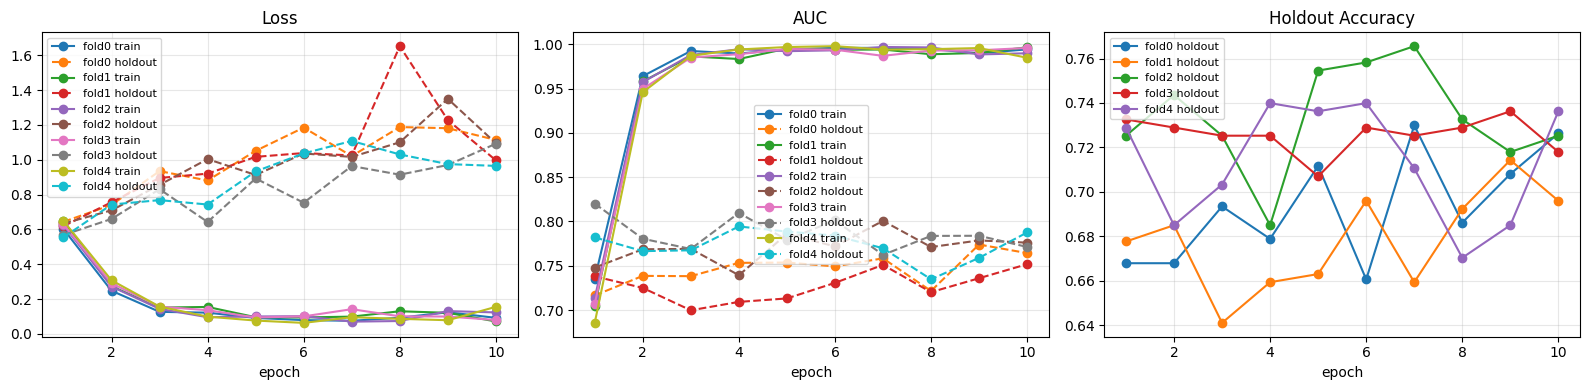

saved curve: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/visualizations/fold_training_curves.png
Final validation passed.
OUTPUT_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel
OOF score CSV: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/oof_mislabel_scores.csv
fold history: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/fold_train_history.csv
top100 summary: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/oof_top100_summary.csv
v2 compare: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/oof_vs_v2_compare.csv
checkpoints: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_oof_mislabel/checkpoints


In [9]:
if FOLD_HISTORY_PATH.exists():
    history_df = pd.read_csv(FOLD_HISTORY_PATH)
else:
    history_df = fold_history_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for fold, part in history_df.groupby("fold", sort=True):
    axes[0].plot(part["epoch"], part["train_loss"], marker="o", label=f"fold{fold} train")
    axes[0].plot(part["epoch"], part["holdout_loss"], marker="o", linestyle="--", label=f"fold{fold} holdout")
    axes[1].plot(part["epoch"], part["train_auc"], marker="o", label=f"fold{fold} train")
    axes[1].plot(part["epoch"], part["holdout_auc"], marker="o", linestyle="--", label=f"fold{fold} holdout")
    axes[2].plot(part["epoch"], part["holdout_acc"], marker="o", label=f"fold{fold} holdout")

axes[0].set_title("Loss")
axes[1].set_title("AUC")
axes[2].set_title("Holdout Accuracy")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(CURVE_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("saved curve:", CURVE_PATH)

required_files = [OOF_SCORE_PATH, FOLD_ASSIGNMENT_PATH, FOLD_HISTORY_PATH, OOF_TOP100_PATH, CONFIG_PATH, CURVE_PATH]
if V2_DETAIL_PATH is not None:
    required_files.append(OOF_VS_V2_COMPARE_PATH)
for path in required_files:
    if not Path(path).exists():
        raise FileNotFoundError(path)

saved_df = pd.read_csv(OOF_SCORE_PATH)
for col in required_output_cols:
    if col not in saved_df.columns:
        raise ValueError(f"saved OOF score missing column: {col}")
if len(saved_df) != 1366:
    raise ValueError(f"saved OOF row count must be 1366, got {len(saved_df)}")
if saved_df["id"].duplicated().any():
    raise ValueError("saved OOF has duplicated ids")
if saved_df["oof_dusty_prob"].isna().any() or saved_df["mislabel_score_oof"].isna().any():
    raise ValueError("saved OOF scores contain NaN")
if not saved_df["oof_dusty_prob"].between(0, 1).all():
    raise ValueError("saved oof_dusty_prob must be in [0, 1]")
if not saved_df["mislabel_score_oof"].between(0, 1).all():
    raise ValueError("saved mislabel_score_oof must be in [0, 1]")

print("Final validation passed.")
print("OUTPUT_DIR:", OUTPUT_DIR)
print("OOF score CSV:", OOF_SCORE_PATH)
print("fold history:", FOLD_HISTORY_PATH)
print("top100 summary:", OOF_TOP100_PATH)
print("v2 compare:", OOF_VS_V2_COMPARE_PATH if V2_DETAIL_PATH is not None else "skipped")
print("checkpoints:", CHECKPOINT_DIR)